## Turma: DADOS - 2025.2

## Materia: RNA e Deep Learning

### Nome: Wagner Ferreira Porto de Vasconcelos

# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.05MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[-0.3712, -0.7332,  0.5392,  0.9563, -1.6731, -0.1388,  0.0382, -0.3425,
         -0.2550,  1.3172]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [7]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [8]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/5], Train Loss: 0.4077, Train Acc: 0.8835, Val Loss: 0.3222, Val Acc: 0.9109
Epoch [2/5], Train Loss: 0.3127, Train Acc: 0.9115, Val Loss: 0.3028, Val Acc: 0.9164
Epoch [3/5], Train Loss: 0.2974, Train Acc: 0.9164, Val Loss: 0.2966, Val Acc: 0.9203
Epoch [4/5], Train Loss: 0.2895, Train Acc: 0.9179, Val Loss: 0.2945, Val Acc: 0.9199
Epoch [5/5], Train Loss: 0.2827, Train Acc: 0.9199, Val Loss: 0.2894, Val Acc: 0.9198


In [9]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2827
Última acurácia de treinamento: 0.9199
Última perda de validação: 0.2894
Última acurácia de validação: 0.9198


### Visualizando a evolução da perda e acurácia

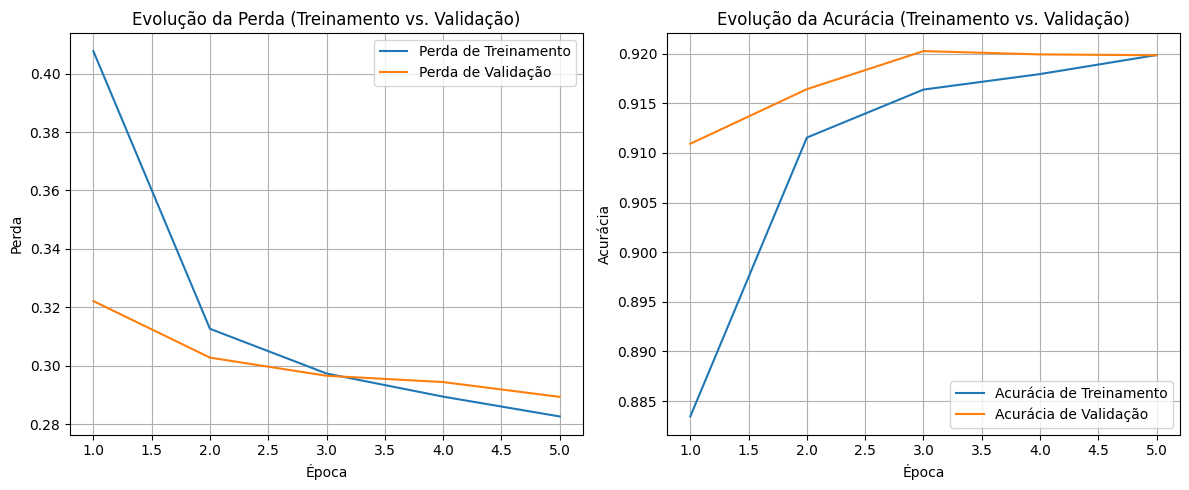

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?

R: 100

2. Em uma época, quantos mini-batches existem?

R: 42000 valores de X_train. 42000/100 = 420 mini-batches

3. Qual é a definição de época?

R: Quando o modelo calcula e ajusta os pesos baseados em todos
os elementos do dataset(em todos os mini batches)

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600


In [11]:
for epoch in range(n_epochs):

    model.train()
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        print(f'Época: {epoch+1}/{n_epochs}, batch: {(i+1) * batch_size}')

Época: 1/5, batch: 100
Época: 1/5, batch: 200
Época: 1/5, batch: 300
Época: 1/5, batch: 400
Época: 1/5, batch: 500
Época: 1/5, batch: 600
Época: 1/5, batch: 700
Época: 1/5, batch: 800
Época: 1/5, batch: 900
Época: 1/5, batch: 1000
Época: 1/5, batch: 1100
Época: 1/5, batch: 1200
Época: 1/5, batch: 1300
Época: 1/5, batch: 1400
Época: 1/5, batch: 1500
Época: 1/5, batch: 1600
Época: 1/5, batch: 1700
Época: 1/5, batch: 1800
Época: 1/5, batch: 1900
Época: 1/5, batch: 2000
Época: 1/5, batch: 2100
Época: 1/5, batch: 2200
Época: 1/5, batch: 2300
Época: 1/5, batch: 2400
Época: 1/5, batch: 2500
Época: 1/5, batch: 2600
Época: 1/5, batch: 2700
Época: 1/5, batch: 2800
Época: 1/5, batch: 2900
Época: 1/5, batch: 3000
Época: 1/5, batch: 3100
Época: 1/5, batch: 3200
Época: 1/5, batch: 3300
Época: 1/5, batch: 3400
Época: 1/5, batch: 3500
Época: 1/5, batch: 3600
Época: 1/5, batch: 3700
Época: 1/5, batch: 3800
Época: 1/5, batch: 3900
Época: 1/5, batch: 4000
Época: 1/5, batch: 4100
Época: 1/5, batch: 4200
É

2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.


=== Treinando com batch_size=16 ===
Época [1/5] Train Loss: 0.4442, Val Loss: 0.4268
Época [2/5] Train Loss: 0.3852, Val Loss: 0.3400
Época [3/5] Train Loss: 0.3743, Val Loss: 0.3891
Época [4/5] Train Loss: 0.3710, Val Loss: 0.3810
Época [5/5] Train Loss: 0.3621, Val Loss: 0.3474

=== Treinando com batch_size=100 ===
Época [1/5] Train Loss: 0.4073, Val Loss: 0.3289
Época [2/5] Train Loss: 0.3124, Val Loss: 0.2985
Época [3/5] Train Loss: 0.2964, Val Loss: 0.3098
Época [4/5] Train Loss: 0.2891, Val Loss: 0.2880
Época [5/5] Train Loss: 0.2823, Val Loss: 0.2890

=== Treinando com batch_size=500 ===
Época [1/5] Train Loss: 0.5850, Val Loss: 0.3999
Época [2/5] Train Loss: 0.3735, Val Loss: 0.3530
Época [3/5] Train Loss: 0.3421, Val Loss: 0.3367
Época [4/5] Train Loss: 0.3255, Val Loss: 0.3235
Época [5/5] Train Loss: 0.3151, Val Loss: 0.3144


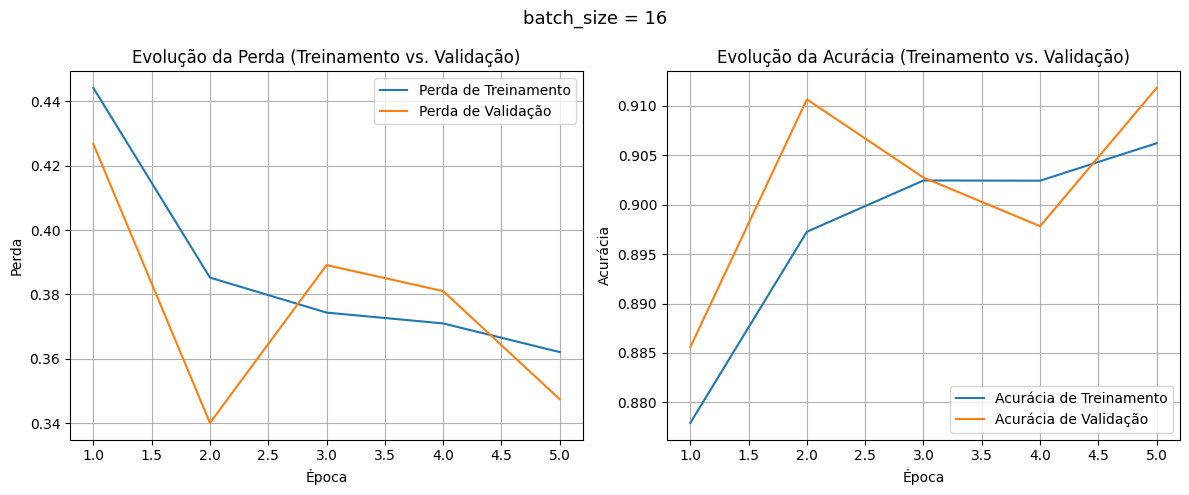

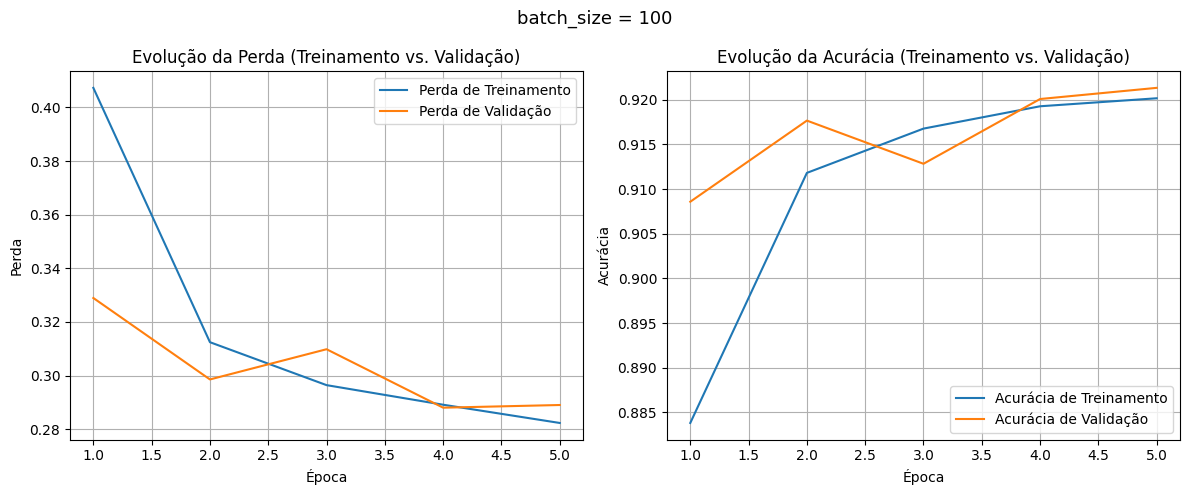

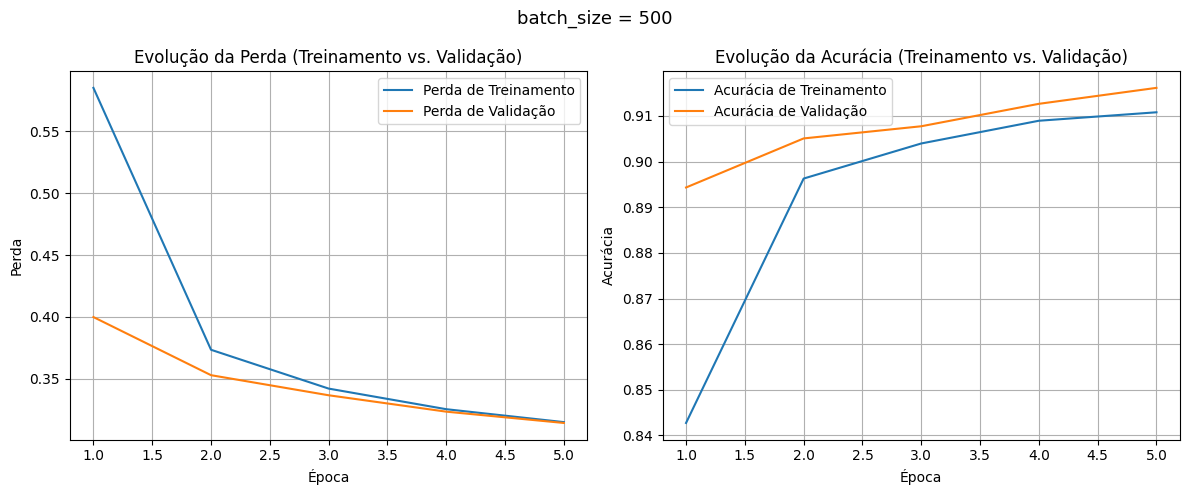

In [13]:
batch_sizes = [16, 100, 500]
results = {}

for batch_size in batch_sizes:
    print(f'\n=== Treinando com batch_size={batch_size} ===')

    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    loader_val   = DataLoader(dataset_val,   batch_size=batch_size, shuffle=False)

    model     = torch.nn.Linear(28*28, 10)
    optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

    train_losses_per_epoch     = []
    val_losses_per_epoch       = []
    train_accuracies_per_epoch = []
    val_accuracies_per_epoch   = []

    for epoch in range(n_epochs):
        # Treino
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train   = 0

        for x_batch, y_batch in loader_train:
            inputs  = x_batch.view(-1, 28*28)
            outputs = model(inputs)
            loss    = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train   += y_batch.size(0)
            correct_train += (predicted == y_batch).sum().item()

        train_losses_per_epoch.append(running_train_loss / len(loader_train))
        train_accuracies_per_epoch.append(correct_train / total_train)

        # Validação
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val   = 0

        with torch.no_grad():
            for x_val, y_val in loader_val:
                inputs_val  = x_val.view(-1, 28*28)
                outputs_val = model(inputs_val)
                loss_val    = criterion(outputs_val, y_val)

                running_val_loss += loss_val.item()
                _, predicted_val = torch.max(outputs_val.data, 1)
                total_val   += y_val.size(0)
                correct_val += (predicted_val == y_val).sum().item()

        val_losses_per_epoch.append(running_val_loss / len(loader_val))
        val_accuracies_per_epoch.append(correct_val / total_val)

        print(f'Época [{epoch+1}/{n_epochs}] '
              f'Train Loss: {train_losses_per_epoch[-1]:.4f}, '
              f'Val Loss: {val_losses_per_epoch[-1]:.4f}')

    results[batch_size] = {
        'train_losses':     train_losses_per_epoch,
        'val_losses':       val_losses_per_epoch,
        'train_accuracies': train_accuracies_per_epoch,
        'val_accuracies':   val_accuracies_per_epoch
    }

for batch_size, metrics in results.items():
    plt.figure(figsize=(12, 5))
    plt.suptitle(f'batch_size = {batch_size}', fontsize=13)

    plt.subplot(1, 2, 1)
    plt.plot(range(1, n_epochs + 1), metrics['train_losses'], label='Perda de Treinamento')
    plt.plot(range(1, n_epochs + 1), metrics['val_losses'],   label='Perda de Validação')
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.title('Evolução da Perda (Treinamento vs. Validação)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, n_epochs + 1), metrics['train_accuracies'], label='Acurácia de Treinamento')
    plt.plot(range(1, n_epochs + 1), metrics['val_accuracies'],   label='Acurácia de Validação')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Conclusões sobre os experimentos deste notebook

- Batches pequenos (ex: 16): Aprendem mais rápido no início, porém a curva de perda é mais irregular e instável

- Batches médios (ex: 100): Melhor equilíbrio entre velocidade e estabilidade. Curva de mais mais suave.

- Batches grandes (ex: 500): Aprendizado mais lento e estável. Curva bem comportada, porém precisa de mais épocas para convergir
